In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('mental_health_workplace.csv')

In [4]:
df.columns

Index(['record_id', 'year', 'country', 'industry', 'job_role',
       'employment_type', 'work_model', 'company_size', 'age_group', 'gender',
       'years_of_experience', 'annual_salary_usd', 'weekly_work_hours',
       'weekly_overtime_hours', 'mental_health_condition', 'has_diagnosis',
       'treatment_type', 'stress_level', 'burnout_risk_score',
       'work_life_balance_score', 'productivity_score',
       'job_satisfaction_score', 'absenteeism_days_per_year',
       'employer_support_level', 'mental_health_policy_exists',
       'eap_available', 'used_eap', 'workplace_stigma_felt',
       'manager_support_score', 'team_collaboration_score',
       'intention_to_leave', 'remote_work_preference',
       'exercise_days_per_week', 'sleep_hours_per_night'],
      dtype='str')

In [5]:
df.head(10)

,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5
5,MHW0000006,2023,France,Technology,Lawyer,Part-time,Hybrid,Startup (1-50),45-54,Male,...,Partial,Yes,No,Mild,8.7,7.2,Very Likely,No Preference,1,8.6
6,MHW0000007,2021,India,Healthcare,Social Worker,Part-time,Hybrid,Enterprise (5000+),35-44,Female,...,No,No,NaN,NaN,9.8,5.5,Very Likely,Prefer On-site,0,6.7
7,MHW0000008,2022,Pakistan,Technology,Social Worker,Part-time,Remote,Enterprise (5000+),25-34,Male,...,Partial,No,NaN,Mild,5.0,7.3,Likely,Prefer Remote,1,8.5
8,MHW0000009,2021,UK,Manufacturing,Social Worker,Part-time,Hybrid,Small (51-200),25-34,Male,...,Yes,No,NaN,Mild,8.0,8.1,Very Unlikely,Strongly Prefer Remote,3,6.0
9,MHW0000010,2022,Netherlands,Finance & Banking,Customer Service,Full-time,On-site,Large (1001-5000),25-34,Female,...,No,Yes,No,Moderate,6.0,5.5,Neutral,Strongly Prefer On-site,0,4.5


In [6]:
df.shape

(10000, 34)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   record_id                    10000 non-null  str    
 1   year                         10000 non-null  int64  
 2   country                      10000 non-null  str    
 3   industry                     10000 non-null  str    
 4   job_role                     10000 non-null  str    
 5   employment_type              10000 non-null  str    
 6   work_model                   10000 non-null  str    
 7   company_size                 10000 non-null  str    
 8   age_group                    10000 non-null  str    
 9   gender                       10000 non-null  str    
 10  years_of_experience          10000 non-null  int64  
 11  annual_salary_usd            10000 non-null  int64  
 12  weekly_work_hours            10000 non-null  int64  
 13  weekly_overtime_hours       

In [8]:
print(pd.crosstab(df['eap_available'], df['used_eap'], dropna=False))

used_eap         No   Yes   NaN
eap_available                  
No                0     0  4812
Yes            3524  1664     0


In [9]:
print(pd.crosstab(df['mental_health_condition'].isna(), df['workplace_stigma_felt'].isna()))

workplace_stigma_felt    False  True 
mental_health_condition              
False                     4803   1847
True                      2365    985


In [10]:
print(pd.crosstab(df['has_diagnosis'], df['workplace_stigma_felt'].isna()))

workplace_stigma_felt  False  True 
has_diagnosis                      
No                      2365    985
Yes                     4803   1847


In [11]:
print(pd.crosstab(df['mental_health_policy_exists'], df['employer_support_level'].isna()))

employer_support_level       False  True 
mental_health_policy_exists              
No                            2791    303
Partial                       2374    273
Yes                           3817    442


In [12]:
df['mental_health_condition'] = df['mental_health_condition'].fillna('None')
df['used_eap'] = df['used_eap'].fillna('Not Applicable')
df['workplace_stigma_felt'] = df['workplace_stigma_felt'].fillna('Not Reported')
df['employer_support_level'] = df['employer_support_level'].fillna('Not Reported')

print(df.isna().sum())

record_id                      0
year                           0
country                        0
industry                       0
job_role                       0
employment_type                0
work_model                     0
company_size                   0
age_group                      0
gender                         0
years_of_experience            0
annual_salary_usd              0
weekly_work_hours              0
weekly_overtime_hours          0
mental_health_condition        0
has_diagnosis                  0
treatment_type                 0
stress_level                   0
burnout_risk_score             0
work_life_balance_score        0
productivity_score             0
job_satisfaction_score         0
absenteeism_days_per_year      0
employer_support_level         0
mental_health_policy_exists    0
eap_available                  0
used_eap                       0
workplace_stigma_felt          0
manager_support_score          0
team_collaboration_score       0
intention_

In [13]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate record_ids:", df['record_id'].duplicated().sum())

print(df.dtypes)

Number of duplicate rows: 0
Number of duplicate record_ids: 0
record_id                          str
year                             int64
country                            str
industry                           str
job_role                           str
employment_type                    str
work_model                         str
company_size                       str
age_group                          str
gender                             str
years_of_experience              int64
annual_salary_usd                int64
weekly_work_hours                int64
weekly_overtime_hours            int64
mental_health_condition            str
has_diagnosis                      str
treatment_type                     str
stress_level                       str
burnout_risk_score             float64
work_life_balance_score        float64
productivity_score             float64
job_satisfaction_score         float64
absenteeism_days_per_year        int64
employer_support_level             str
me

In [14]:
print(df.describe())

               year  years_of_experience  annual_salary_usd  \
count  10000.000000         10000.000000       10000.000000   
mean    2022.151300            14.492500       86779.311900   
std        1.334086            10.053509       24022.505197   
min     2020.000000             0.000000       36140.000000   
25%     2021.000000             6.000000       68216.000000   
50%     2022.000000            13.000000       84816.000000   
75%     2023.000000            21.000000      102633.250000   
max     2024.000000            44.000000      177599.000000   

       weekly_work_hours  weekly_overtime_hours  burnout_risk_score  \
count       10000.000000           10000.000000        10000.000000   
mean           45.155000               6.564600            4.027030   
std             8.629115               6.806692            2.304458   
min            20.000000               0.000000            1.000000   
25%            39.000000               0.000000            2.200000   
50%   

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation = df[numeric_cols].corr()['burnout_risk_score'].sort_values(ascending=False)
print(correlation)

burnout_risk_score           1.000000
weekly_work_hours            0.747205
weekly_overtime_hours        0.746912
absenteeism_days_per_year    0.354931
annual_salary_usd            0.240667
manager_support_score        0.003187
years_of_experience         -0.001335
year                        -0.003676
sleep_hours_per_night       -0.004098
exercise_days_per_week      -0.006563
team_collaboration_score    -0.011973
job_satisfaction_score      -0.131091
productivity_score          -0.239119
work_life_balance_score     -0.483002
Name: burnout_risk_score, dtype: float64


In [17]:

df['manager_support_bin'] = pd.cut(df['manager_support_score'], 
                                     bins=[0, 4, 6, 8, 10], 
                                     labels=['Low (0-4)', 'Medium (4-6)', 'High (6-8)', 'Very High (8-10)'])


print(df.groupby('manager_support_bin')['burnout_risk_score'].agg(['mean', 'count']))

                         mean  count
manager_support_bin                 
Low (0-4)            4.009134   1489
Medium (4-6)         4.027206   2878
High (6-8)           4.042313   2862
Very High (8-10)     4.020678   2771


In [18]:
categorical_cols = ['industry', 'job_role', 'country', 'age_group', 'gender', 'company_size']

for col in categorical_cols:
    print(f"\n=== Average Burnout by {col} ===")
    print(df.groupby(col)['burnout_risk_score'].agg(['mean', 'count']).sort_values('mean', ascending=False))


=== Average Burnout by industry ===
                                mean  count
industry                                   
Finance & Banking           4.944675   1061
Consulting                  4.929661    590
Technology                  4.892538   1702
Legal                       4.809565    460
Healthcare                  4.450900   1222
Pharmaceuticals             3.391135    282
Nonprofit                   3.361688    308
Government & Public Sector  3.331014    690
Construction                3.330402    398
Media & Entertainment       3.254003    587
Retail & E-commerce         3.246999    683
Hospitality                 3.241667    276
Manufacturing               3.231128    771
Education                   3.100722    970

=== Average Burnout by job_role ===
                          mean  count
job_role                             
Financial Analyst     4.168632    475
Teacher               4.138583    508
Designer              4.133835    532
Sales Representative  4.116079  

In [19]:
print(df.groupby('industry')[['burnout_risk_score', 'weekly_work_hours', 'weekly_overtime_hours']].mean().sort_values('burnout_risk_score', ascending=False))

                            burnout_risk_score  weekly_work_hours  \
industry                                                            
Finance & Banking                     4.944675          49.671065   
Consulting                            4.929661          49.413559   
Technology                            4.892538          49.289659   
Legal                                 4.809565          49.078261   
Healthcare                            4.450900          46.901800   
Pharmaceuticals                       3.391135          41.592199   
Nonprofit                             3.361688          42.168831   
Government & Public Sector            3.331014          41.417391   
Construction                          3.330402          41.866834   
Media & Entertainment                 3.254003          41.620102   
Retail & E-commerce                   3.246999          41.512445   
Hospitality                           3.241667          41.235507   
Manufacturing                     

In [20]:
print(df.groupby('intention_to_leave')['burnout_risk_score'].agg(['mean', 'count']).sort_values('mean', ascending=False))

                        mean  count
intention_to_leave                 
Very Likely         4.092622   1003
Likely              4.081910   1990
Very Unlikely       4.045662   1706
Unlikely            4.014128   2810
Neutral             3.958571   2491


In [21]:
leave_mapping = {
    'Very Unlikely': 1,
    'Unlikely': 2,
    'Neutral': 3,
    'Likely': 4,
    'Very Likely': 5
}
df['intention_to_leave_numeric'] = df['intention_to_leave'].map(leave_mapping)

print(df[['burnout_risk_score', 'intention_to_leave_numeric']].corr())

                            burnout_risk_score  intention_to_leave_numeric
burnout_risk_score                    1.000000                    0.007529
intention_to_leave_numeric            0.007529                    1.000000


In [22]:
wlb_correlations = df[['work_life_balance_score', 'productivity_score', 'job_satisfaction_score', 'burnout_risk_score']].corr()['work_life_balance_score']
print(wlb_correlations.sort_values(ascending=False))

work_life_balance_score    1.000000
productivity_score        -0.002676
job_satisfaction_score    -0.014726
burnout_risk_score        -0.483002
Name: work_life_balance_score, dtype: float64


In [23]:
print(df.groupby('mental_health_policy_exists')[['burnout_risk_score', 'job_satisfaction_score', 'work_life_balance_score']].mean())
print()
print(df.groupby('eap_available')[['burnout_risk_score', 'job_satisfaction_score', 'work_life_balance_score']].mean())

                             burnout_risk_score  job_satisfaction_score  \
mental_health_policy_exists                                               
No                                     4.067453                5.847156   
Partial                                3.988364                5.852323   
Yes                                    4.021695                5.896830   

                             work_life_balance_score  
mental_health_policy_exists                           
No                                          6.416257  
Partial                                     6.448017  
Yes                                         6.450951  

               burnout_risk_score  job_satisfaction_score  \
eap_available                                               
No                       4.033978                5.838653   
Yes                      4.020586                5.898458   

               work_life_balance_score  
eap_available                           
No                   

In [24]:
print(df.groupby('work_model')[['burnout_risk_score', 'productivity_score', 'job_satisfaction_score']].agg(['mean', 'count']))

           burnout_risk_score       productivity_score        \
                         mean count               mean count   
work_model                                                     
Hybrid               4.144687  3567           6.446341  3567   
On-site              4.082941  3441           6.442546  3441   
Remote               3.822460  2992           6.413536  2992   

           job_satisfaction_score        
                             mean count  
work_model                               
Hybrid                   5.863527  3567  
On-site                  5.885469  3441  
Remote                   5.858857  2992  


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

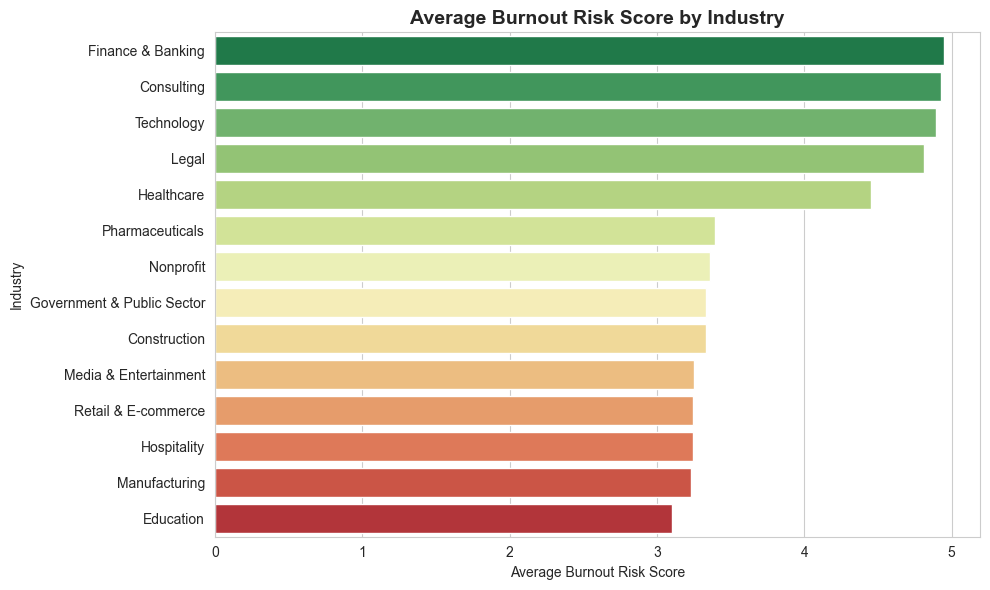

In [27]:
plt.figure(figsize=(10, 6))
industry_burnout = df.groupby('industry')['burnout_risk_score'].mean().sort_values(ascending=False)

sns.barplot(x=industry_burnout.values, y=industry_burnout.index, hue=industry_burnout.index, palette='RdYlGn_r', legend=False)
plt.title('Average Burnout Risk Score by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Average Burnout Risk Score')
plt.ylabel('Industry')
plt.tight_layout()
plt.savefig('chart1_burnout_by_industry.png', dpi=300, bbox_inches='tight')
plt.show()

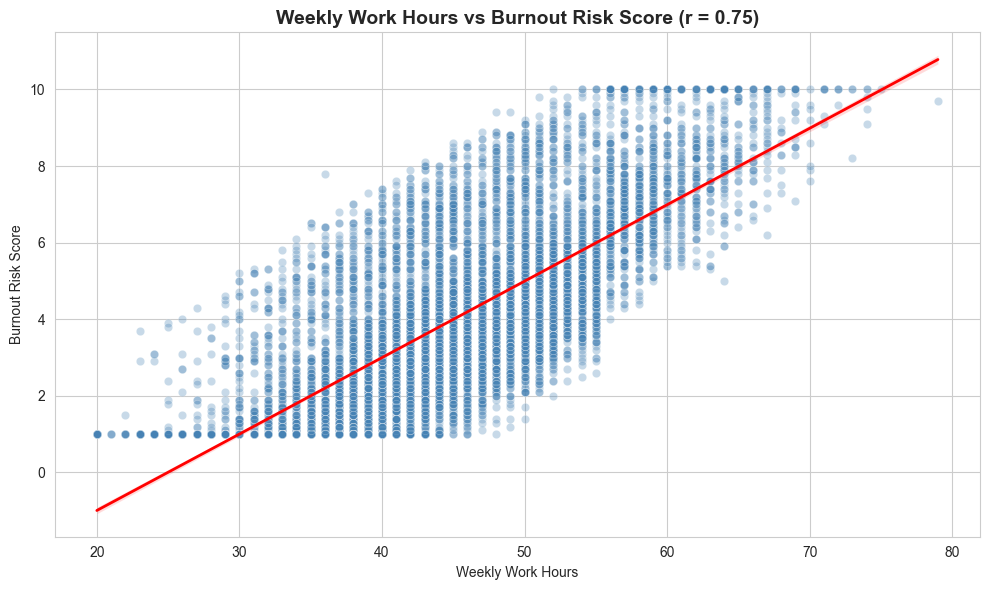

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weekly_work_hours', y='burnout_risk_score', alpha=0.3, color='steelblue')
sns.regplot(data=df, x='weekly_work_hours', y='burnout_risk_score', scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Weekly Work Hours vs Burnout Risk Score (r = 0.75)', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Work Hours')
plt.ylabel('Burnout Risk Score')
plt.tight_layout()
plt.savefig('chart2_workhours_vs_burnout.png', dpi=300, bbox_inches='tight')
plt.show()

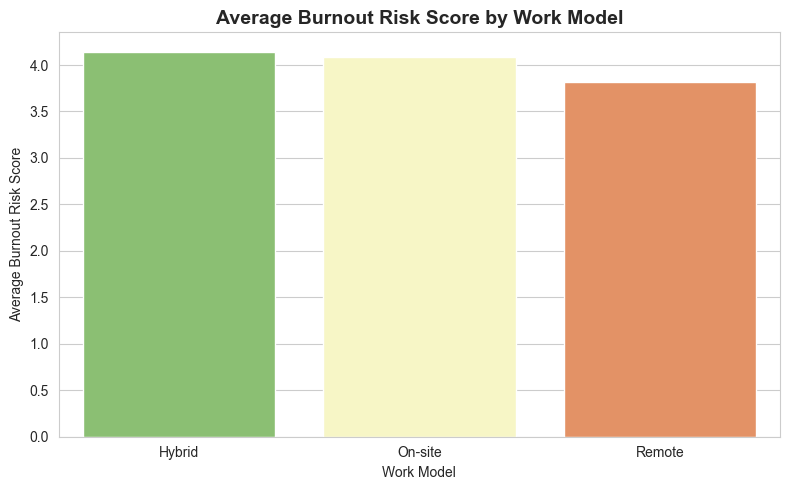

In [30]:
plt.figure(figsize=(8, 5))
workmodel_burnout = df.groupby('work_model')['burnout_risk_score'].mean().sort_values(ascending=False)

sns.barplot(x=workmodel_burnout.index, y=workmodel_burnout.values, hue=workmodel_burnout.index, palette='RdYlGn_r', legend=False)
plt.title('Average Burnout Risk Score by Work Model', fontsize=14, fontweight='bold')
plt.xlabel('Work Model')
plt.ylabel('Average Burnout Risk Score')
plt.tight_layout()
plt.savefig('chart3_burnout_by_workmodel.png', dpi=300, bbox_inches='tight')
plt.show()

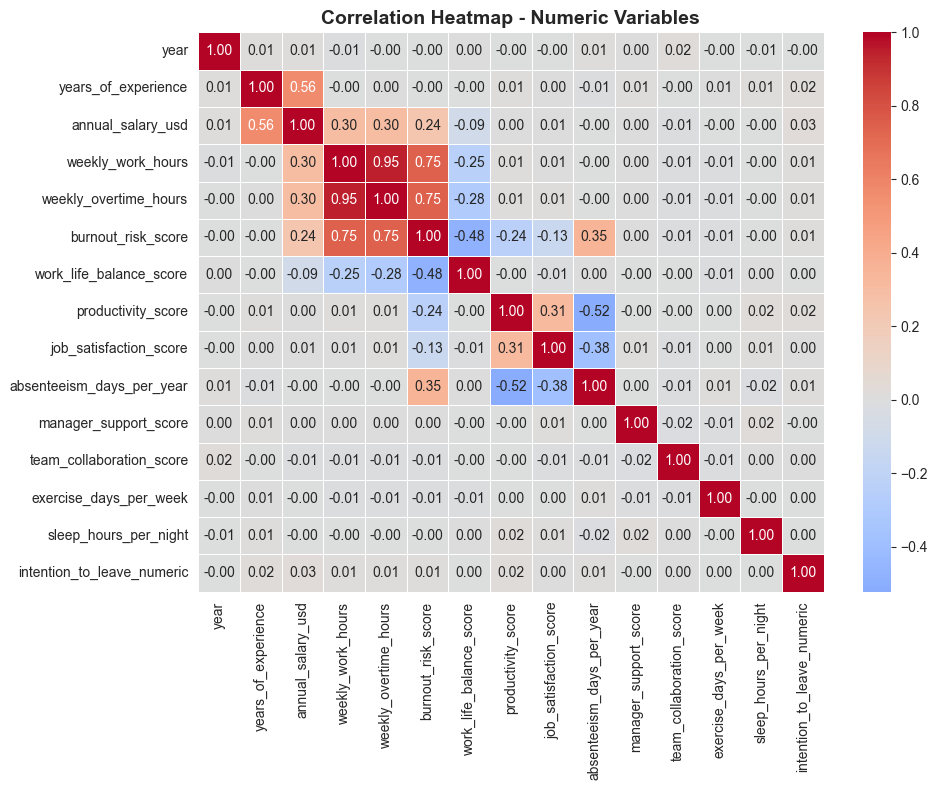

In [31]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

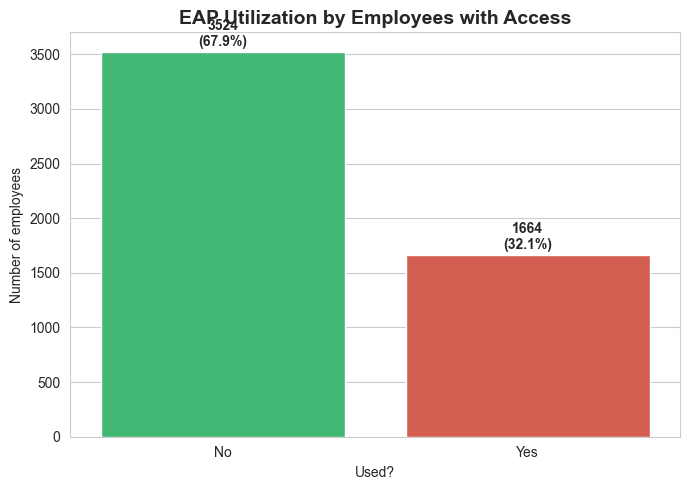

In [32]:
eap_data = df[df['eap_available'] == 'Yes']
eap_usage = eap_data['used_eap'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=eap_usage.index, y=eap_usage.values, hue=eap_usage.index, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('EAP Utilization by Employees with Access', fontsize=14, fontweight='bold')
plt.xlabel('Used?')
plt.ylabel('Number of employees')

total = eap_usage.sum()
for i, v in enumerate(eap_usage.values):
    plt.text(i, v + 50, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_eap_utilization.png', dpi=300, bbox_inches='tight')
plt.show()

# HR Analytics: Employee Mental Health & Retention Analysis
## Phase 1 — Data Cleaning & Exploratory Data Analysis (Python)

### 1. Data Cleaning

The dataset consists of 10,000 rows and 34 columns, with no duplicate records. Four columns had 
missing values, each handled based on verified patterns rather than assumptions:

| Column | Missing | Root Cause | Treatment |
|---|---|---|---|
| `mental_health_condition` | 33.5% | Skip logic — NaN means no condition reported (verified via `has_diagnosis`) | Filled with `"None"` |
| `used_eap` | 48.1% | Skip logic — NaN means employer doesn't offer EAP | Filled with `"Not Applicable"` |
| `workplace_stigma_felt` | 28.3% | Missing At Random (~28% consistent across groups) | Filled with `"Not Reported"` |
| `employer_support_level` | 10.2% | Missing At Random (~10% consistent across groups) | Filled with `"Not Reported"` |

### 2. Key Drivers of Burnout

Pearson correlation with `burnout_risk_score`:
- **Weekly work hours: r = 0.75** (strong, positive)
- **Weekly overtime hours: r = 0.75** (strong, positive)
- **Work-life balance score: r = -0.48** (moderate, negative — protective factor)
- Absenteeism days: r = 0.35 (moderate)
- Manager support score: r = 0.003 (no relationship, confirmed via non-linear/binning analysis)

**Conclusion**: Burnout is primarily driven by workload (hours worked & overtime), not managerial support.

### 3. Groups with Highest Burnout

- **Industry** is the strongest differentiating factor (1.84-point gap): Finance & Banking, 
  Consulting, Technology, and Legal rank well above average, while Education and Manufacturing 
  rank lowest.
- Cross-checking confirms industry acts as a **proxy for work culture**: high-burnout industries 
  consistently show ~49 work hours/week and ~10 overtime hours/week, versus ~41 hours and ~3.5 
  overtime hours in low-burnout industries.
- Job role, country, age group, gender, and company size show much smaller variation (<0.5 points), 
  indicating these are not primary drivers.

### 4. Burnout vs Intention to Leave

Correlation is near zero (r = 0.0075). **Burnout does not appear to predict resignation intent** 
in this dataset — the decision to stay or leave is likely driven by other factors (job market 
conditions, compensation, personal ties).

### 5. Work-Life Balance vs Productivity, Satisfaction, and Burnout

Work-life balance correlates strongly with burnout only (r = -0.48), but shows **no meaningful 
relationship** with productivity (r = -0.003) or job satisfaction (r = -0.015). WLB is an effective 
protective factor against burnout, but not a direct driver of performance or satisfaction.

### 6. Mental Health Policy & EAP vs Employee Wellbeing

Differences in burnout, job satisfaction, and work-life balance between companies with and without 
formal policies/EAP are **under 0.08 points across all metrics** — practically negligible.

Supporting finding: among employees with EAP access, **~68% never use it**. This suggests the core 
issue isn't policy availability, but rather low **utilization and awareness** of existing programs.

### 7. Remote Work vs Burnout, Productivity, and Satisfaction

Remote work is associated with lower burnout (3.82) compared to Hybrid (4.14) and On-site (4.08), 
but shows no significant impact on productivity or job satisfaction (differences under 0.04 points). 
Notably, Hybrid shows the highest burnout — even higher than On-site.

---

## Executive Summary

Burnout in this dataset is primarily driven by **workload** (work hours & overtime), with 
work-life balance serving as the main protective factor. Industry acts as a marker of work 
culture rather than a direct cause. In contrast, interventions intuitively expected to help — 
manager support, formal policies, EAP — **show no measurable effect**, likely due to implementation 
or utilization gaps rather than program availability itself.

**Initial Business Recommendations:**
1. Prioritize reducing work hours and overtime in Finance, Consulting, Technology, and Legal.
2. Direct EAP investment toward improving awareness and accessibility, rather than launching new programs.
3. Encourage remote work adoption as a lever to reduce burnout without performance trade-offs.
4. Avoid relying on increased manager support as a primary burnout reduction strategy — allocate 
   resources to factors with proven impact instead.

In [33]:
df.to_csv('mental_health_workplace_cleaned.csv', index=False)